In [13]:
%pip install numpy pandas matplotlib


3704.51s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


You should consider upgrading via the '/Users/macbook/Github/ai-core-labs/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import pandas as pd

# Gerçekçi bir yapay zeka veri seti simülasyonu
data = {
    "Ogrenci_ID": [101, 102, 103, 104, 105],
    "Calisma_Saati": [2.5, 5.1, 1.8, 8.0, 6.2],
    "Deneme_Neti": [45, 78, 38, 92, 85],
    "Gecti_Mi": [0, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

# Veri seti hakkında temel istatistiksel özet
print("--- Veri Seti Özeti ---")
df.info()

df

--- Veri Seti Özeti ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ogrenci_ID     5 non-null      int64  
 1   Calisma_Saati  5 non-null      float64
 2   Deneme_Neti    5 non-null      int64  
 3   Gecti_Mi       5 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 288.0 bytes


,Ogrenci_ID,Calisma_Saati,Deneme_Neti,Gecti_Mi
0,101,2.5,45,0
1,102,5.1,78,1
2,103,1.8,38,0
3,104,8.0,92,1
4,105,6.2,85,1


In [15]:
# 1. Filtreleme: Çalışma saati 4'ten fazla olan öğrencileri filtrele
basarili_ogrenciler = df[df["Calisma_Saati"] > 4.0]
print("--- Günde 4 Saatten Fazla Çalışanlar ---")
print(basarili_ogrenciler[["Ogrenci_ID", "Calisma_Saati", "Deneme_Neti"]])

# 2. Yeni Özellik Üretimi (Feature Engineering):
# Her çalışma saati başına kaç net kazanılmış? (Verimlilik Skoru)
df["Verimlilik_Skoru"] = df["Deneme_Neti"] / df["Calisma_Saati"]

# 3. İstatiksel Özet: Ortalama, Min, Max değerleri
print("\n--- Verimlilik ve Net İstatistikleri ---")
df[["Deneme_Neti", "Verimlilik_Skoru"]].describe()

--- Günde 4 Saatten Fazla Çalışanlar ---
   Ogrenci_ID  Calisma_Saati  Deneme_Neti
1         102            5.1           78
3         104            8.0           92
4         105            6.2           85

--- Verimlilik ve Net İstatistikleri ---


,Deneme_Neti,Verimlilik_Skoru
count,5.000000,5.000000
mean,67.600000,15.922981
std,24.460172,3.744584
min,38.000000,11.500000
25%,45.000000,13.709677
50%,78.000000,15.294118
75%,85.000000,18.000000
max,92.000000,21.111111


### 2. Eksik Veri Yönetimi (Imputation) ve Keşifsel Veri Analizi (EDA)

* **Eksik Veri (NaN) Problemi:** Yapay zeka modelleri matris çarpımlarıyla ($Y = WX + b$) çalışır. Matristeki tek bir `NaN` değeri gradyan hesaplarını bozar ve eğitimi çökertir.
* **Mean Imputation:** Eksik gözlemleri serinin beklenen değeri ($\mathbb{E}[X]$) yani ortalama ile tamamlarız. Aykırı değerler (outliers) varsa medyan tercih edilmelidir.
* **Görselleştirme (EDA):** Veriyi eğitmeden önce bağımsız değişken ($X$) ile bağımlı değişken ($y$) arasındaki korelasyonu görmek için dağılım grafiği (scatter plot) çizilir.

=== HAM VERİ ===
  Ogrenci  Calisma_Saati  Deneme_Neti
0     Ali            2.5           45
1    Ayşe            NaN           88
2  Mehmet            1.8           38
3  Zeynep            8.0           92
4     Can            6.2           85
5    Elif            NaN           60

=== DOLDURULMUŞ VERİ (Ortalama: 4.62) ===
  Ogrenci  Calisma_Saati  Deneme_Neti
0     Ali          2.500           45
1    Ayşe          4.625           88
2  Mehmet          1.800           38
3  Zeynep          8.000           92
4     Can          6.200           85
5    Elif          4.625           60


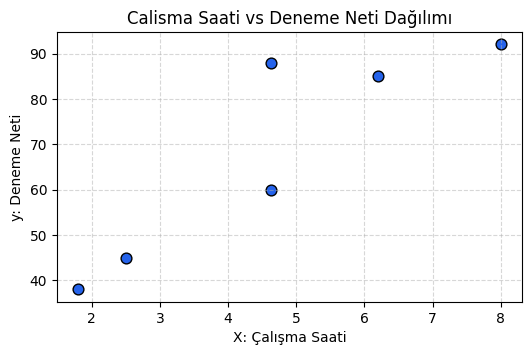

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Eksik veri içeren gözlem matrisi simülasyonu
raw_data = {
    "Ogrenci": ["Ali", "Ayşe", "Mehmet", "Zeynep", "Can", "Elif"],
    "Calisma_Saati": [2.5, np.nan, 1.8, 8.0, 6.2, np.nan],
    "Deneme_Neti": [45, 88, 38, 92, 85, 60]
}

df_eksik = pd.DataFrame(raw_data)
print("=== HAM VERİ ===")
print(df_eksik)

# 2. Ortalama ile eksik değer tamamlama
ortalama_saat = df_eksik["Calisma_Saati"].mean()
df_eksik["Calisma_Saati"] = df_eksik["Calisma_Saati"].fillna(ortalama_saat)

print(f"\n=== DOLDURULMUŞ VERİ (Ortalama: {ortalama_saat:.2f}) ===")
print(df_eksik)

# 3. Dağılım Grafiği (Scatter Plot)
plt.figure(figsize=(6, 3.5))
plt.scatter(df_eksik["Calisma_Saati"], df_eksik["Deneme_Neti"], color="#2563EB", s=60, edgecolors="black")
plt.title("Calisma Saati vs Deneme Neti Dağılımı")
plt.xlabel("X: Çalışma Saati")
plt.ylabel("y: Deneme Neti")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Mühendislik & Teori: Lineer Regresyon Nedir?
Bir yazılım mühendisi geleneksel programlamada kuralı kendisi yazar:
Girdi + Mantık (if/else) = Çıktı

Makine öğrenmesinde ise tersidir:
Girdi (X) + Çıktı (y) = Algoritmanın bulduğu Mantık/Kural (Model)

Modelin yapacağı şey, dağılım grafiğindeki noktaların arasından geçen en ideal doğruyu bulmaktır:
y=w⋅X+b
X: Bağımsız değişken (Feature / Özellik): Çalışma Saati
y: Bağımlı değişken (Target / Hedef): Sınav Notu
w (Weight / Ağırlık): Doğrunun eğimi. "Çalışılan her 1 saat nota kaç puan ekler?"
b (Bias / Kayan Değer): Başlangıç noktası. "Hiç çalışmayan biri ortalama kaç alır?"
Model, Mean Squared Error (MSE) fonksiyonunu minimize ederek en kusursuz w ve b değerlerini öğrenecek.

In [17]:
%pip install scikit-learn


3711.16s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


You should consider upgrading via the '/Users/macbook/Github/ai-core-labs/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### 3. Klasik Makine Öğrenmesi: Lineer Regresyon (Supervised Learning)
* **Amaç:** Girdi ($X$) ve hedef ($y$) arasındaki doğrusal ilişkiyi modellemek ($y = wX + b$).
* **Ağırlık ($w$ - Weight):** Girdinin çıktı üzerindeki etki katsayısı (Eğim).
* **Sapma ($b$ - Bias):** Tüm girdiler sıfır olduğunda beklenen taban çıktı.
* **Loss Fonksiyonu:** Model gerçek değer ile tahmin arasındaki farkın karesini (MSE) en aza indirmeye çalışır.

Öğrenilen Ağırlık (w): 8.36
Öğrenilen Bias (b): 27.89
Model Denklemi: y = 8.36 * X + 27.89

--> 6.5 saat çalışan bir öğrencinin tahmini notu: 82.21


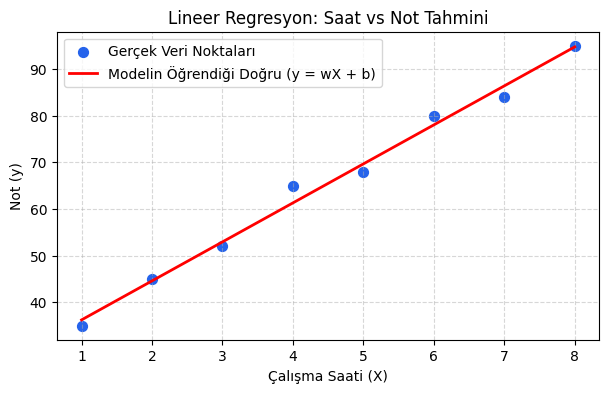

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Eğitim Verisini Hazırla (X iki boyutlu matris olmalıdır: [örnek_sayısı, özellik_sayısı])
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0]]) # Çalışma saatleri
y = np.array([35, 45, 52, 65, 68, 80, 84, 95])                          # Sınav notları

# 2. Modeli Başlat ve Eğit (Fit işlemi optimizasyonu çalıştırır)
model = LinearRegression()
model.fit(X, y)

# 3. Modelin Öğrendiği Parametreler
w = model.coef_[0]
b = model.intercept_
print(f"Öğrenilen Ağırlık (w): {w:.2f}")
print(f"Öğrenilen Bias (b): {b:.2f}")
print(f"Model Denklemi: y = {w:.2f} * X + {b:.2f}")

# 4. Geleceğe Yönelik Tahmin (Inference): Günde 6.5 saat çalışan biri kaç alır?
yeni_ogrenci = np.array([[6.5]])
tahmin = model.predict(yeni_ogrenci)
print(f"\n--> 6.5 saat çalışan bir öğrencinin tahmini notu: {tahmin[0]:.2f}")

# 5. Modelin Çizdiği Regresyon Doğrusunu Görselleştir
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color="#2563EB", label="Gerçek Veri Noktaları", s=50)
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Modelin Öğrendiği Doğru (y = wX + b)")
plt.title("Lineer Regresyon: Saat vs Not Tahmini")
plt.xlabel("Çalışma Saati (X)")
plt.ylabel("Not (y)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 4. Model Değerlendirme (Evaluation Metrics)
* **R² (R-Squared) Skoru:** Modelin verideki varyansı açıklama oranı ($0$ ile $1$ arası). $1$'e ne kadar yakınsa model o kadar başarılıdır.
* **MAE (Mean Absolute Error):** Modelin tahminlerindeki ortalama mutlak hata payı (örneğin $\pm$ kaç puan saptığı).

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Modelin mevcut öğrenciler için yaptığı tahminleri al
y_pred = model.predict(X)

# 2. Metrikleri hesapla
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"=== Model Başarı Karnesi ===")
print(f"R² Skoru (Başarı Oranı) : {r2:.4f} (Yani yaklaşık %{r2*100:.1f})")
print(f"Ortalama Hata Payı (MAE) : ±{mae:.2f} puan")

# 3. Gerçek Değerler ile Modelin Tahminlerini Yan Yana Gör
karsilastirma = pd.DataFrame({
    "Çalışma Saati": X.flatten(),
    "Gerçek Not": y,
    "Modelin Tahmini": np.round(y_pred, 1),
    "Fark (Hata)": np.round(np.abs(y - y_pred), 1)
})
print("\n=== Tahmin vs Gerçek Değer Tablosu ===")
print(karsilastirma)

=== Model Başarı Karnesi ===
R² Skoru (Başarı Oranı) : 0.9903 (Yani yaklaşık %99.0)
Ortalama Hata Payı (MAE) : ±1.57 puan

=== Tahmin vs Gerçek Değer Tablosu ===
   Çalışma Saati  Gerçek Not  Modelin Tahmini  Fark (Hata)
0            1.0          35             36.2          1.2
1            2.0          45             44.6          0.4
2            3.0          52             53.0          1.0
3            4.0          65             61.3          3.7
4            5.0          68             69.7          1.7
5            6.0          80             78.0          2.0
6            7.0          84             86.4          2.4
7            8.0          95             94.8          0.2
